# Multiple Instance Learning on CAMELYON16
### Mark Sterkel, David Rath

Three MIL aggregation strategies on CAMELYON16 lymph node histopathology. Each bag is a whole-slide image (WSI); instances are 512-pixel tissue patches. The task: classify each slide as cancerous or normal from bag-level labels only.

Features are precomputed ResNet-50 Barlow Twins embeddings (2048-dim). No CNN encoder needed; the model aggregates patch embeddings directly.

| **Aggregator** | **Test AUC** |
|----------------|:------------:|
| Mean pooling   |    0.8140    |
| Max pooling    |  **0.9921**  |
| ABMIL (gated attention) |   0.9668    |

1. CAMELYON16 Dataset
2. Model
3. Training
4. Analysis & Visualisation

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
from torchmil.datasets import CAMELYON16MILDataset

In [2]:
from torchmil.datasets.processed_mil_dataset import ProcessedMILDataset
from tensordict import TensorDict as _TensorDict

def _read_only_cache_getitem(self, index):
    """Serve from cache if present, otherwise load from disk without caching.

    The default torchmil __getitem__ caches every loaded bag permanently, which
    exhausts RAM when iterating large datasets. This version lets us pre-load a
    fixed val set into cache while train/test slides stay off-heap.
    """
    bag_name = self.bag_names[index]
    bag_dict = self.loaded_bags[bag_name] if bag_name in self.loaded_bags else self._build_bag(bag_name)
    return _TensorDict({k: bag_dict[k] for k in self.bag_keys if k in bag_dict})

ProcessedMILDataset.__getitem__ = _read_only_cache_getitem

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
PROJECT_ROOT = '.'

DATA_DIR    = f'{PROJECT_ROOT}/data/camelyon16'
DATASET_DIR = f'{DATA_DIR}/dataset'   # torchmil root: contains patches_512/ and splits.csv
CKPT_DIR    = f'{PROJECT_ROOT}/checkpoints'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

In [5]:
import tarfile
from huggingface_hub import snapshot_download

_features_dir = f"{DATASET_DIR}/patches_512/features/features_resnet50_bt"

if os.path.isdir(_features_dir) and os.listdir(_features_dir):
    print("Dataset exists")
else:
    # Download all archives to DATA_DIR (~63 GB; resumes automatically if interrupted).
    snapshot_download(
        repo_id="torchmil/Camelyon16_MIL",
        repo_type="dataset",
        local_dir=DATA_DIR,
    )

    # Extract each .tar.gz into the subdirectory torchmil expects.
    # Archives use flat paths, so each one extracts into its own named folder.
    _patches = f"{DATASET_DIR}/patches_512"
    _to_extract = [
        (f"{_patches}/coords.tar.gz",                         f"{_patches}/coords"),
        (f"{_patches}/labels.tar.gz",                         f"{_patches}/labels"),
        (f"{_patches}/patch_labels.tar.gz",                   f"{_patches}/patch_labels"),
        (f"{_patches}/features/features_resnet50_bt.tar.gz",  _features_dir),
    ]
    for src, dest in _to_extract:
        if os.path.isdir(dest) and os.listdir(dest):
            print(f"Already extracted: {os.path.basename(src)}")
            continue
        os.makedirs(dest, exist_ok=True)
        print(f"Extracting {os.path.basename(src)} ...", end=" ", flush=True)
        with tarfile.open(src) as t:
            t.extractall(dest, filter="data")
        print("done")

Dataset exists


In [6]:
features_path = os.path.join(DATASET_DIR, 'patches_512', 'features', 'features_resnet50_bt')
print(f"Features extracted: {os.path.isdir(features_path)}")
if os.path.isdir(features_path):
    npy_files = [f for f in os.listdir(features_path) if f.endswith('.npy')]
    print(f"  {len(npy_files)} slide files")

Features extracted: True
  399 slide files


In [7]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## CAMELYON16 Dataset

In [8]:
from sklearn.model_selection import train_test_split

FEATURES         = 'resnet50_bt'
VAL_FRACTION     = 0.2
LOAD_AT_INIT     = False

# On SSD: each slide (~70 MB) reads in <0.15s, so using all slides per epoch is practical.
# Set to an integer (e.g. 80) to limit per epoch if on HDD.
SLIDES_PER_EPOCH = None

# Full CAMELYON16 test set (all 130 slides). Set to an integer (e.g. 50) to subsample for fast dev.
MAX_TEST_SLIDES = None

full_train_ds = CAMELYON16MILDataset(
    root=DATASET_DIR,
    features=FEATURES,
    partition='train',
    bag_keys=['X', 'Y', 'y_inst', 'coords'],
    load_at_init=LOAD_AT_INIT,
)
test_ds = CAMELYON16MILDataset(
    root=DATASET_DIR,
    features=FEATURES,
    partition='test',
    bag_keys=['X', 'Y', 'y_inst', 'coords'],
    load_at_init=LOAD_AT_INIT,
)

if MAX_TEST_SLIDES is not None and MAX_TEST_SLIDES < len(test_ds):
    _sub = np.random.default_rng(SEED).choice(len(test_ds), size=MAX_TEST_SLIDES, replace=False).tolist()
    test_ds = test_ds.subset(_sub)

FEAT_DIM = full_train_ds[0]['X'].shape[1]
print(f"Feature dimension: {FEAT_DIM}  |  Train pool: {len(full_train_ds)} slides  |  Test: {len(test_ds)} slides")

train_labels_all = np.array([arr.item() for arr in full_train_ds.get_bag_labels()])
test_labels_arr  = np.array([arr.item() for arr in test_ds.get_bag_labels()])

# Stratified split: guarantees the same positive/negative ratio in train and val.
train_indices, val_indices = train_test_split(
    np.arange(len(full_train_ds)),
    test_size=VAL_FRACTION,
    stratify=train_labels_all,
    random_state=SEED,
)

val_ds = Subset(full_train_ds, val_indices)

train_labels = train_labels_all[train_indices]
val_labels   = train_labels_all[val_indices]

# Pre-load val slides into cache once — reused every epoch at RAM speed.
# Train and test slides are never cached (no accumulation).
for i in tqdm(val_indices, desc='pre-caching val slides', leave=False):
    name = full_train_ds.bag_names[i]
    if name not in full_train_ds.loaded_bags:
        full_train_ds.loaded_bags[name] = full_train_ds._build_bag(name)

for split, labels in [("Train pool", train_labels), ("Val  ", val_labels), ("Test ", test_labels_arr)]:
    pos = labels.sum()
    print(f"{split}: {len(labels)} slides  ({pos} positive, {len(labels)-pos} negative)")

Feature dimension: 2048  |  Train pool: 270 slides  |  Test: 129 slides


pre-caching val slides:   0%|          | 0/54 [00:00<?, ?it/s]

Train pool: 216 slides  (89 positive, 127 negative)
Val  : 54 slides  (22 positive, 32 negative)
Test : 129 slides  (49 positive, 80 negative)


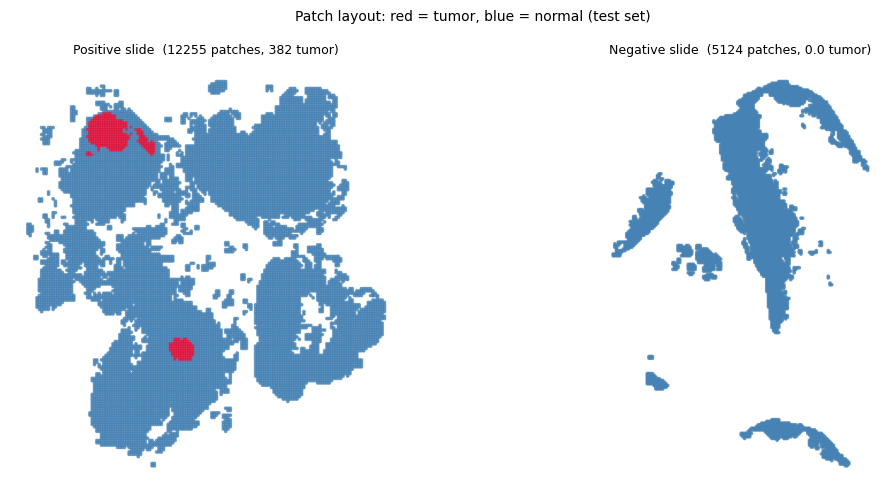

In [9]:
# Show patch layout for one positive and one negative test slide.
# Each point is one patch; colour encodes the ground truth patch label.
pos_slide_idx = [i for i, lbl in enumerate(test_labels_arr) if lbl == 1]
neg_slide_idx = [i for i, lbl in enumerate(test_labels_arr) if lbl == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, slide_idx, split_label in zip(axes, [pos_slide_idx[0], neg_slide_idx[0]], ['Positive', 'Negative']):
    item   = test_ds[slide_idx]
    coords = item['coords'].numpy()    # (N, 2)
    y_inst = item['y_inst'].numpy()    # (N,)
    colors = np.where(y_inst, 'crimson', 'steelblue')
    ax.scatter(coords[:, 0], -coords[:, 1], c=colors, s=3, alpha=0.7)
    ax.set_title(
        f"{split_label} slide  ({len(y_inst)} patches, {y_inst.sum()} tumor)",
        fontsize=9
    )
    ax.set_aspect('equal')
    ax.axis('off')
plt.suptitle("Patch layout: red = tumor, blue = normal (test set)", fontsize=10)
plt.tight_layout()
plt.show()

### Dataset Statistics

- **Bag size distribution**: patches per WSI.
- **Positive / negative split**: slides with vs. without tumor patches.
- **Tumor patch fraction**: tumor patch rate in positive test slides.

train bag sizes:   0%|          | 0/270 [00:00<?, ?it/s]

test bag sizes:   0%|          | 0/129 [00:00<?, ?it/s]

tumor fracs:   0%|          | 0/129 [00:00<?, ?it/s]

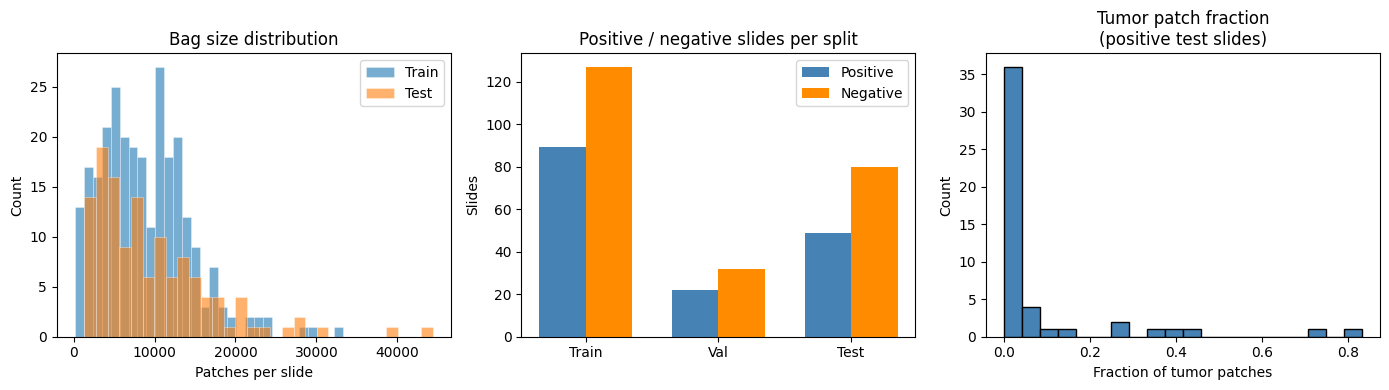

Patches per slide: mean=8764  min=140  max=33333


In [10]:
_coord_path       = os.path.join(DATASET_DIR, 'patches_512', 'coords')
_label_path       = os.path.join(DATASET_DIR, 'patches_512', 'labels')
_patch_label_path = os.path.join(DATASET_DIR, 'patches_512', 'patch_labels')

# Read coord files (tiny, ~2 KB each) instead of feature files (~60 MB each)
train_bag_sizes = [
    np.load(os.path.join(_coord_path, n + '.npy')).shape[0]
    for n in tqdm(full_train_ds.get_bag_names(), desc='train bag sizes', leave=False)
]
test_bag_sizes = [
    np.load(os.path.join(_coord_path, n + '.npy')).shape[0]
    for n in tqdm(test_ds.get_bag_names(), desc='test bag sizes', leave=False)
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.hist(train_bag_sizes, bins=30, alpha=0.6, label='Train', edgecolor='white', linewidth=0.4)
ax.hist(test_bag_sizes,  bins=30, alpha=0.6, label='Test',  edgecolor='white', linewidth=0.4)
ax.set_xlabel("Patches per slide")
ax.set_ylabel("Count")
ax.set_title("Bag size distribution")
ax.legend()

ax = axes[1]
splits_bar = [("Train", train_labels), ("Val", val_labels), ("Test", test_labels_arr)]
x = np.arange(len(splits_bar))
w = 0.35
pos_c = [lbl.sum() for _, lbl in splits_bar]
neg_c = [len(lbl) - p for (_, lbl), p in zip(splits_bar, pos_c)]
ax.bar(x - w/2, pos_c, w, label="Positive", color="steelblue")
ax.bar(x + w/2, neg_c, w, label="Negative", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels([s for s, _ in splits_bar])
ax.set_ylabel("Slides")
ax.set_title("Positive / negative slides per split")
ax.legend()

ax = axes[2]
tumor_fracs = []
for name in tqdm(test_ds.get_bag_names(), desc='tumor fracs', leave=False):
    lbl = np.load(os.path.join(_label_path, name + '.npy')).item()
    if lbl == 1:
        pl = np.load(os.path.join(_patch_label_path, name + '.npy'))
        tumor_fracs.append(pl.mean())
ax.hist(tumor_fracs, bins=20, edgecolor='black', color='steelblue')
ax.set_xlabel("Fraction of tumor patches")
ax.set_ylabel("Count")
ax.set_title("Tumor patch fraction\n(positive test slides)")

plt.tight_layout()
plt.show()

print(f"Patches per slide: mean={np.mean(train_bag_sizes):.0f}  "
      f"min={min(train_bag_sizes)}  max={max(train_bag_sizes)}")

## Model

In [11]:
class FeatureProjector(nn.Module):
    """Two fc-512 layers with dropout before MIL pooling (Ilse et al., Table 15).

    Since input features are precomputed ResNet-50 Barlow Twins embeddings rather
    than raw pixels, the CNN layers are omitted; the two fc layers serve as the
    embedding refinement step matching the paper's histopathology architecture.

    Args:
        in_dim:  Input feature dimension (FEAT_DIM, e.g. 2048 for resnet50_bt).
        out_dim: Output dimension passed to the aggregator.
        dropout: Dropout probability applied after each fc layer.

    Input:  (N, in_dim)
    Output: (N, out_dim)
    """

    def __init__(self, in_dim: int, out_dim: int = 512, dropout: float = 0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):    # (N, in_dim)
        return self.net(x)   # (N, out_dim)


class MeanPoolAggregator(nn.Module):
    """Element-wise mean over instance features."""

    def forward(self, h):
        return h.mean(dim=0, keepdim=True), None


class MaxPoolAggregator(nn.Module):
    """Element-wise max over instance features."""

    def forward(self, h):
        return h.max(dim=0, keepdim=True).values, None


class AttentionAggregator(nn.Module):
    """Gated attention aggregator (Ilse et al., ICML 2018).

    Attention score per instance:
        a_i = softmax( w^T ( tanh(V h_i) o sigmoid(U h_i) ) )

    Bag representation:
        z = sum_i a_i h_i

    Args:
        L: Input feature dimension (must match projector output).
        D: Internal attention dimension.
    """

    def __init__(self, L: int = 500, D: int = 128):
        super().__init__()
        self.V = nn.Linear(L, D)
        self.U = nn.Linear(L, D)
        self.w = nn.Linear(D, 1)

    def forward(self, h):                                               # (N, L)
        a = self.w(torch.tanh(self.V(h)) * torch.sigmoid(self.U(h)))  # (N, 1)
        a = torch.softmax(a, dim=0)                                    # (N, 1)
        z = (a * h).sum(dim=0, keepdim=True)                           # (1, L)
        return z, a.squeeze(1)                                         # (1, L), (N,)


class MILModel(nn.Module):
    """Feature projector + aggregator + binary bag classifier.

    Always returns (logit, attention_weights), where attention_weights is None
    for non-adaptive aggregators.

    Args:
        projector:   FeatureProjector instance.
        aggregator:  One of MeanPoolAggregator, MaxPoolAggregator, AttentionAggregator.
        hidden_dim:  Projector output / aggregator input dimension.
    """

    def __init__(self, projector: nn.Module, aggregator: nn.Module, hidden_dim: int = 500):
        super().__init__()
        self.projector  = projector
        self.aggregator = aggregator
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, X):                           # (N, feat_dim)
        h          = self.projector(X)              # (N, hidden_dim)
        z, weights = self.aggregator(h)             # (1, hidden_dim), (N,) or None
        logit      = self.classifier(z).squeeze()   # scalar
        return logit, weights

In [12]:
HIDDEN_DIM = 512
ATTN_DIM   = 128
DROPOUT    = 0.25

_X = torch.randn(200, FEAT_DIM)   # 200 patches, realistic bag
for name, agg in [("mean", MeanPoolAggregator()),
                  ("max",  MaxPoolAggregator()),
                  ("attn", AttentionAggregator(HIDDEN_DIM, ATTN_DIM))]:
    model = MILModel(FeatureProjector(FEAT_DIM, HIDDEN_DIM, DROPOUT), agg, HIDDEN_DIM)
    logit, w = model(_X)
    w_shape  = tuple(w.shape) if w is not None else None
    print(f"{name:4s}  logit={tuple(logit.shape)}  weights={w_shape}")

mean  logit=()  weights=None
max   logit=()  weights=None
attn  logit=()  weights=(200,)


## Training

In [13]:
EPOCHS                  = 100
LR                      = 1e-4
WEIGHT_DECAY            = 5e-4
EARLY_STOPPING_PATIENCE = 10

criterion = nn.BCEWithLogitsLoss()

def _collate(batch):
    return batch[0]

# Separate lightweight dataset instance for the training loader.
# Using full_train_ds here would also work, but that object holds the pre-cached
# val slides (~4 GB). Keeping it separate avoids accidental cross-contamination
# and skips loading y_inst/coords, which training does not need.
_train_ds = CAMELYON16MILDataset(
    root=DATASET_DIR,
    features=FEATURES,
    partition='train',
    bag_keys=['X', 'Y'],
    load_at_init=False,
)

# num_workers > 0 is intentionally not used here. On Windows, DataLoader workers
# are spawned as separate processes (Python's "spawn" start method). The dataset
# object — including torchmil internals and tensordict state — must be fully
# picklable to be sent to each worker. In practice this causes immediate worker
# crashes on Windows + Jupyter regardless of dataset size. num_workers=0 loads
# each slide in the main process; the disk read (~0.15 s/slide) is the bottleneck
# but avoids all multiprocessing instability.
train_loader = DataLoader(
    Subset(_train_ds, train_indices),
    batch_size=1, shuffle=True, collate_fn=_collate,
    num_workers=0,
)

# Val and test loaders: slides are served from the main-process in-memory cache
# (loaded_bags), so num_workers=0 is correct here regardless.
val_loader  = DataLoader(val_ds,  batch_size=1, shuffle=False, collate_fn=_collate, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=_collate, num_workers=0)

In [14]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best      = float('inf')

    def step(self, val_loss):
        if val_loss < (self.best - self.min_delta):
            self.best    = val_loss
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for item in loader:
        X = item['X'].to(device)
        Y = item['Y'].float().squeeze().to(device)
        optimizer.zero_grad()
        logit, _ = model(X)
        loss = criterion(logit, Y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_full(model, loader, criterion, device):
    """Returns (val_loss, val_auc) in a single pass — avoids iterating the loader twice."""
    model.eval()
    total_loss, probs, labels = 0.0, [], []
    with torch.no_grad():
        for item in loader:
            X = item['X'].to(device)
            Y = item['Y'].float().squeeze().to(device)
            logit, _ = model(X)
            total_loss += criterion(logit, Y).item()
            probs.append(torch.sigmoid(logit).item())
            labels.append(int(Y.item()))
    return total_loss / len(loader), roc_auc_score(labels, probs)


def evaluate(model, loader, device):
    """Returns AUC on the given loader."""
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for item in loader:
            X = item['X'].to(device)
            logit, _ = model(X)
            probs.append(torch.sigmoid(logit).item())
            labels.append(int(item['Y'].item()))
    return roc_auc_score(labels, probs)


def plot_confusion_matrix(model, loader, device, name):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for item in loader:
            X = item['X'].to(device)
            logit, _ = model(X)
            preds.append((torch.sigmoid(logit) > 0.5).int().item())
            labels.append(int(item['Y'].item()))
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Neg', 'Pos'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Neg', 'Pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} confusion matrix')
    plt.tight_layout()
    plt.show()

mean:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 58


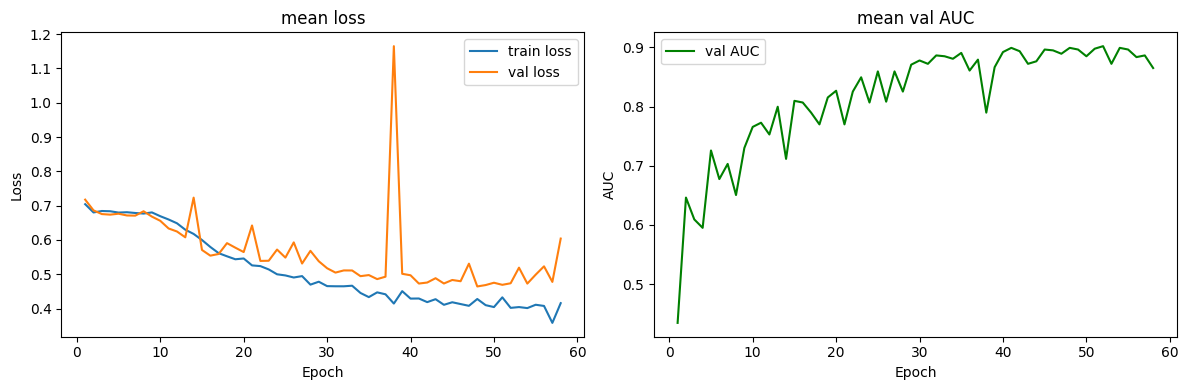

  mean  AUC=0.8140


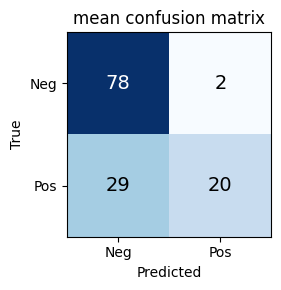

max:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 38


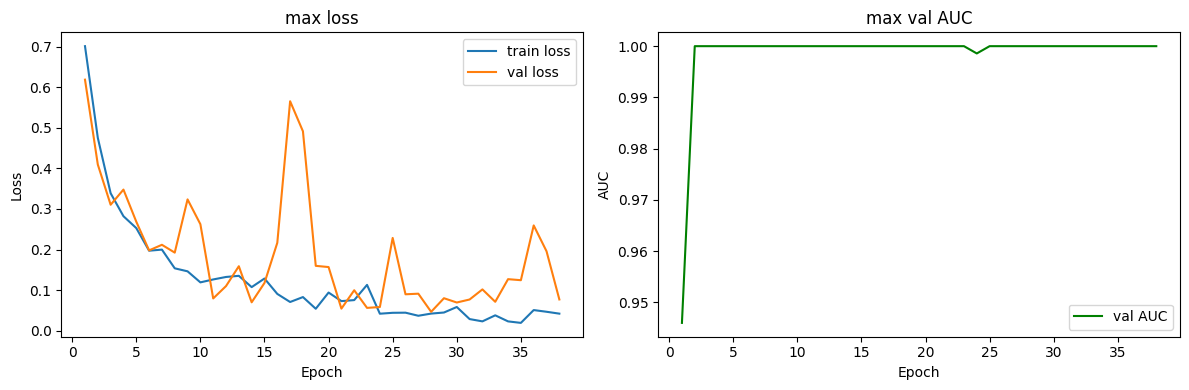

  max   AUC=0.9921


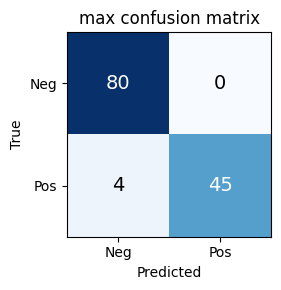

attn:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 36


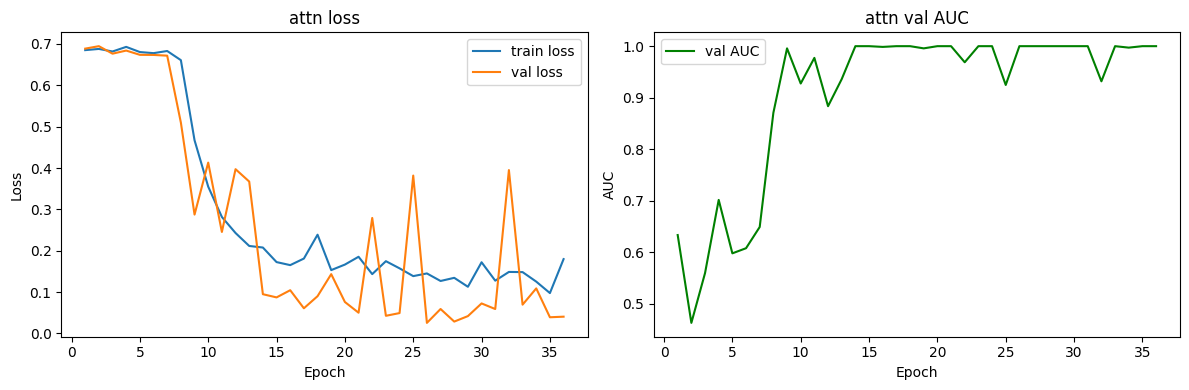

  attn  AUC=0.9668


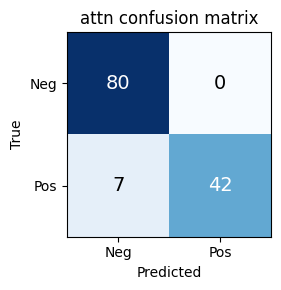

In [15]:
trained_models = {}

configs = [
    ("mean", MeanPoolAggregator()),
    ("max",  MaxPoolAggregator()),
    ("attn", AttentionAggregator(HIDDEN_DIM, ATTN_DIM)),
]

for name, agg in configs:
    model     = MILModel(FeatureProjector(FEAT_DIM, HIDDEN_DIM, DROPOUT), agg, HIDDEN_DIM).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    stopper   = EarlyStopper(patience=EARLY_STOPPING_PATIENCE, min_delta=1e-3)

    train_losses, val_losses, val_aucs = [], [], []
    best_state = None

    pbar = tqdm(range(1, EPOCHS + 1), desc=name)
    for epoch in pbar:
        train_loss        = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_auc = evaluate_full(model, val_loader, criterion, DEVICE)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_aucs.append(val_auc)

        if val_loss <= stopper.best:
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        should_stop = stopper.step(val_loss)
        pbar.set_postfix(tr=f'{train_loss:.3f}', val=f'{val_loss:.3f}',
                         auc=f'{val_auc:.3f}', es=f'{stopper.counter}/{stopper.patience}')
        if should_stop:
            print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    epochs_ran = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs_ran, train_losses, label='train loss')
    ax1.plot(epochs_ran, val_losses,   label='val loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{name} loss'); ax1.legend()
    ax2.plot(epochs_ran, val_aucs, color='green', label='val AUC')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
    ax2.set_title(f'{name} val AUC'); ax2.legend()
    plt.tight_layout(); plt.show()

    torch.save(model.state_dict(), f"{CKPT_DIR}/camelyon_{name}.pt")
    test_auc = evaluate(model, test_loader, DEVICE)
    print(f"  {name:4s}  AUC={test_auc:.4f}")
    plot_confusion_matrix(model, test_loader, DEVICE, name)
    trained_models[name] = model

In [16]:
# Load trained checkpoints to skip retraining after a kernel restart
trained_models = {}
for name, agg in [("mean", MeanPoolAggregator()),
                  ("max",  MaxPoolAggregator()),
                  ("attn", AttentionAggregator(HIDDEN_DIM, ATTN_DIM))]:
    model = MILModel(FeatureProjector(FEAT_DIM, HIDDEN_DIM, DROPOUT), agg, HIDDEN_DIM).to(DEVICE)
    model.load_state_dict(torch.load(f"{CKPT_DIR}/camelyon_{name}.pt", weights_only=True))
    model.eval()
    trained_models[name] = model
    print(f"Loaded  {name}")

Loaded  mean
Loaded  max
Loaded  attn


In [17]:
# re-run after a kernel restart to restore analysis state without retraining
attn_model = trained_models["attn"]
attn_model.eval()

test_pos_indices = [i for i, lbl in enumerate(test_labels_arr) if lbl == 1]
chosen = np.random.default_rng(SEED).choice(
    test_pos_indices, size=min(4, len(test_pos_indices)), replace=False
)

## Analysis & Visualisation

Do high-attention patches correspond to actual tumor tissue?

### ROC Curves

ROC curves:   0%|          | 0/3 [00:00<?, ?it/s]

mean:   0%|          | 0/129 [00:00<?, ?it/s]

  mean    AUC = 0.8140


max:   0%|          | 0/129 [00:00<?, ?it/s]

  max     AUC = 0.9921


attn:   0%|          | 0/129 [00:00<?, ?it/s]

  attn    AUC = 0.9668


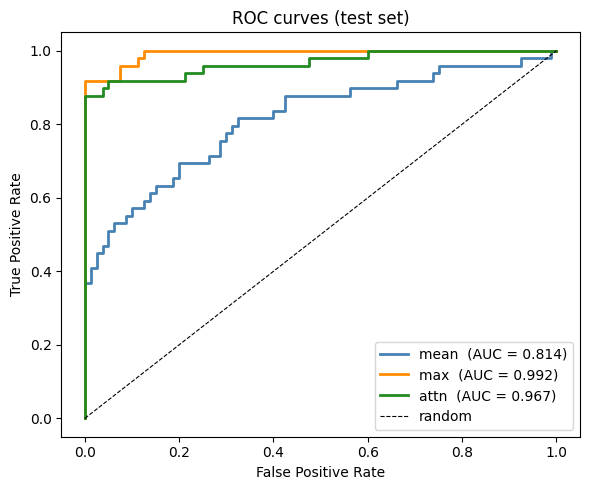

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = {"mean": "steelblue", "max": "darkorange", "attn": "forestgreen"}

for name, model in tqdm(trained_models.items(), desc='ROC curves', position=0, leave=True):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for item in tqdm(test_loader, desc=name, position=1, leave=False):
            X = item['X'].to(DEVICE)
            logit, _ = model(X)
            probs.append(torch.sigmoid(logit).item())
            labels.append(int(item['Y'].item()))
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", color=colors[name], linewidth=2)
    print(f"  {name:6s}  AUC = {auc:.4f}")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves (test set)")
ax.legend()
plt.tight_layout()
plt.show()

### Instance-Level AUC

Patch-level ground truth is available in CAMELYON16, so attention weights can be checked against true patch labels.

**Scale caveat.** Softmax weights scale as 1/N, and slide sizes range from 140 to 33,000 patches. Raw weights are not comparable across slides: a small-slide patch scores ~0.005 while a large-slide patch scores ~0.00003. A global AUC therefore disadvantages tumor patches, which sit in large positive slides. The rank distribution below corrects for this.

In [19]:
inst_labels_all, inst_attn_all = [], []

attn_model.eval()
with torch.no_grad():
    for item in tqdm(test_loader, desc='instance AUC', leave=False):
        X = item['X'].to(DEVICE)
        _, attn_w = attn_model(X)
        inst_labels_all.append(item['y_inst'].numpy())
        inst_attn_all.append(attn_w.cpu().numpy())

inst_labels_flat = np.concatenate(inst_labels_all).astype(int)
inst_attn_flat   = np.concatenate(inst_attn_all)

inst_auc = roc_auc_score(inst_labels_flat, inst_attn_flat)
n_pos = inst_labels_flat.sum()
n_neg = len(inst_labels_flat) - n_pos
print(f"Instance-level AUC (raw attention, cross-slide): {inst_auc:.4f}")
print(f"  {n_pos} tumor patches,  {n_neg} normal  ({len(inst_labels_flat)} total)")
print(f"  Note: AUC < 0.5 is expected here due to the 1/N scale artifact described above.")
print(f"  See the rank distribution below for a scale-corrected view.")

instance AUC:   0%|          | 0/129 [00:00<?, ?it/s]

Instance-level AUC (raw attention, cross-slide): 0.4419
  64032 tumor patches,  1187230 normal  (1251262 total)
  Note: AUC < 0.5 is expected here due to the 1/N scale artifact described above.
  See the rank distribution below for a scale-corrected view.


### Spatial Attention Maps

**Left:** ground truth (crimson = tumor, steelblue = normal). **Right:** ABMIL attention, normalised per slide to [0, 1] (viridis: dark = low, yellow = high).

Overlap between yellow regions and tumor patches means the model localises pathological tissue directly.

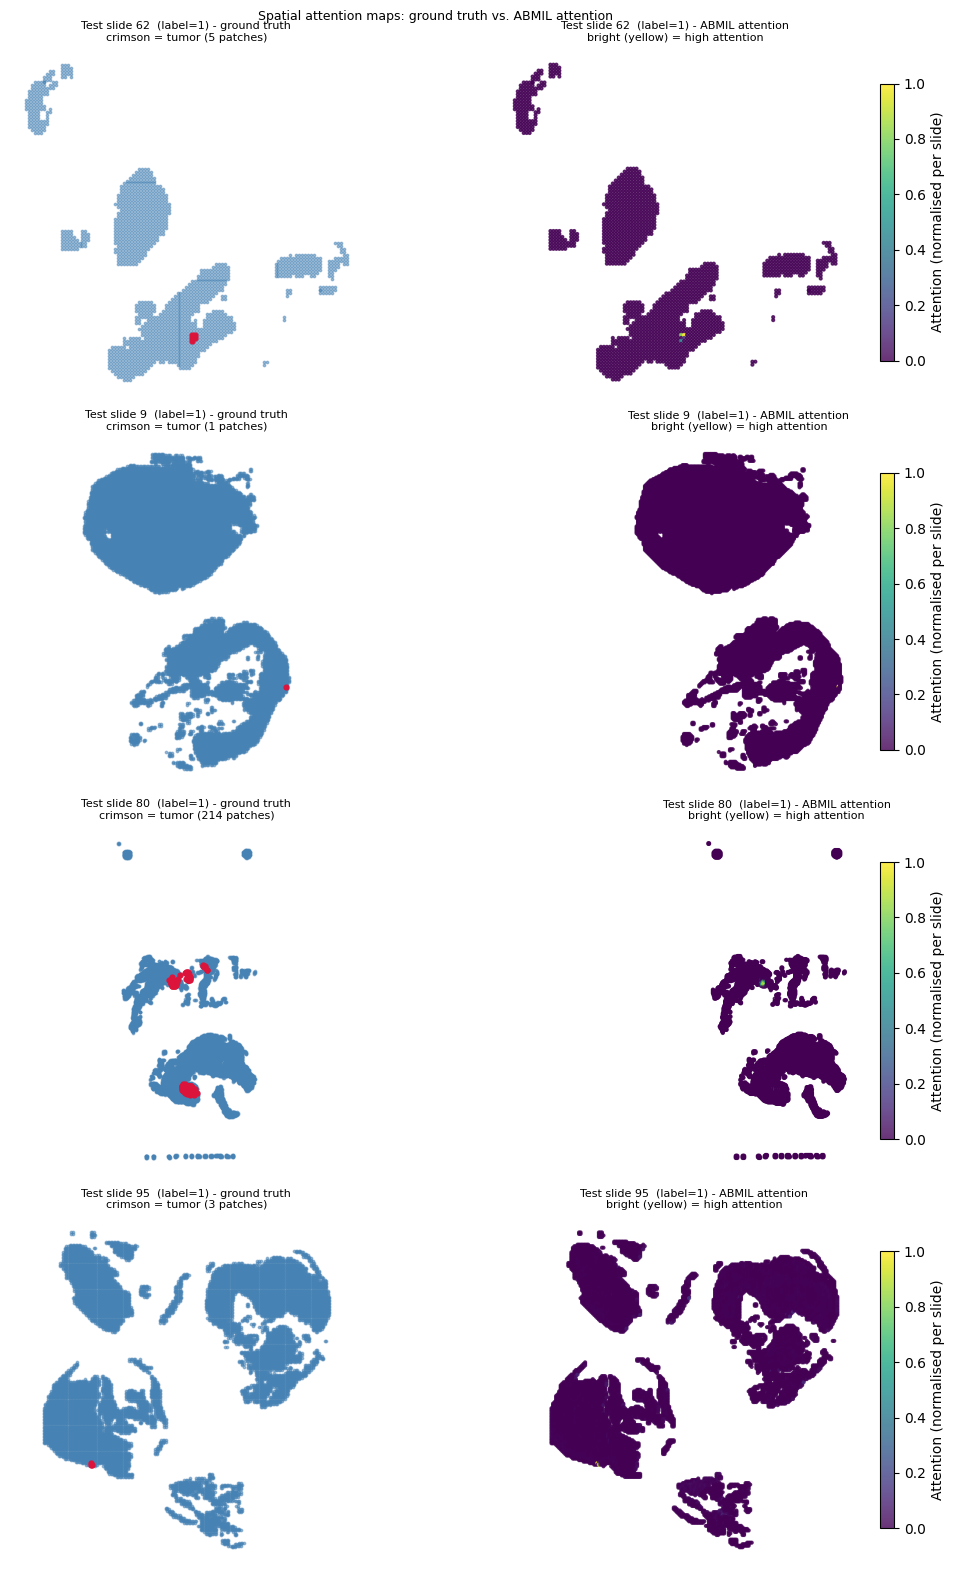

In [20]:
fig, axes = plt.subplots(len(chosen), 2, figsize=(11, 4 * len(chosen)))
if len(chosen) == 1:
    axes = axes[np.newaxis, :]

for row, idx in enumerate(chosen):
    item   = test_ds[idx]
    X      = item['X'].to(DEVICE)
    coords = item['coords'].numpy()    # (N, 2)
    y_inst = item['y_inst'].numpy()    # (N,)
    label  = int(item['Y'].item())

    with torch.no_grad():
        _, attn_w = attn_model(X)
    attn_w = attn_w.cpu().numpy()
    # Per-slide min-max normalisation: all slides share the same [0, 1] colour scale
    attn_w_norm = (attn_w - attn_w.min()) / (attn_w.max() - attn_w.min() + 1e-10)

    # --- Ground truth ---
    ax = axes[row, 0]
    normal_mask = y_inst == 0
    tumor_mask  = y_inst == 1
    ax.scatter(coords[normal_mask, 0], -coords[normal_mask, 1],
               c='steelblue', s=3, alpha=0.5)
    if tumor_mask.any():
        # Overlay tumor patches larger and fully opaque so small clusters stay visible
        ax.scatter(coords[tumor_mask, 0], -coords[tumor_mask, 1],
                   c='crimson', s=12, alpha=1.0, zorder=5)
    n_tumor = int(tumor_mask.sum())
    ax.set_title(f"Test slide {idx}  (label={label}) - ground truth\n"
                 f"crimson = tumor ({n_tumor} patches)", fontsize=8)
    ax.set_aspect('equal')
    ax.axis('off')

    # --- ABMIL attention ---
    ax = axes[row, 1]
    sc = ax.scatter(coords[:, 0], -coords[:, 1], c=attn_w_norm,
                    cmap='viridis', vmin=0, vmax=1, s=4, alpha=0.8)
    plt.colorbar(sc, ax=ax, label="Attention (normalised per slide)", shrink=0.8)
    ax.set_title(f"Test slide {idx}  (label={label}) - ABMIL attention\n"
                 f"bright (yellow) = high attention", fontsize=8)
    ax.set_aspect('equal')
    ax.axis('off')

plt.suptitle("Spatial attention maps: ground truth vs. ABMIL attention", fontsize=9)
plt.tight_layout()
plt.show()

### Attention Weight Distribution

Softmax over thousands of patches gives weights near 1/N; histograms of raw values collapse to a spike at 0.

Instead: **within-slide rank percentile** (0 = lowest attention, 1 = highest). A flat distribution means random attention; a right shift for tumor patches means the model ranks them higher.

attn distribution:   0%|          | 0/129 [00:00<?, ?it/s]

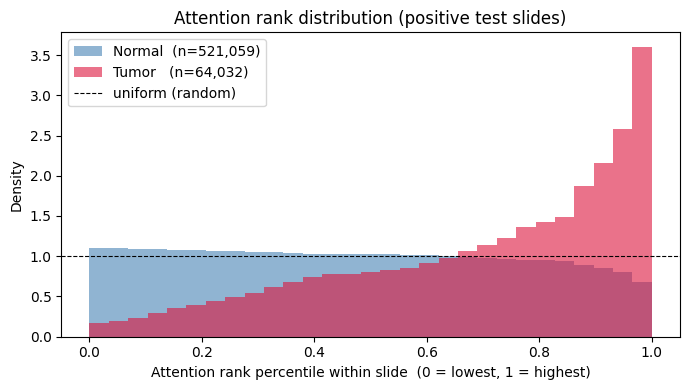

Mean rank — tumor: 0.691  normal: 0.477  (random baseline: 0.500)


In [21]:
tumor_ranks_all, normal_ranks_all = [], []

attn_model.eval()
with torch.no_grad():
    for item in tqdm(test_loader, desc='attn distribution', leave=False):
        if item['Y'].item() != 1:
            continue
        X      = item['X'].to(DEVICE)
        y_inst = item['y_inst'].numpy()
        _, attn_w = attn_model(X)
        attn_w = attn_w.cpu().numpy()

        n = len(attn_w)
        # Double argsort → 0-indexed rank; divide by (n-1) → [0, 1]
        ranks = np.argsort(np.argsort(attn_w)) / (n - 1)

        tumor_ranks_all.extend(ranks[y_inst == 1].tolist())
        normal_ranks_all.extend(ranks[y_inst == 0].tolist())

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 30)
ax.hist(normal_ranks_all, bins=bins, alpha=0.6, density=True,
        label=f"Normal  (n={len(normal_ranks_all):,})", color='steelblue')
ax.hist(tumor_ranks_all, bins=bins, alpha=0.6, density=True,
        label=f"Tumor   (n={len(tumor_ranks_all):,})", color='crimson')
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, label='uniform (random)')
ax.set_xlabel("Attention rank percentile within slide  (0 = lowest, 1 = highest)")
ax.set_ylabel("Density")
ax.set_title("Attention rank distribution (positive test slides)")
ax.legend()
plt.tight_layout()
plt.show()

if tumor_ranks_all and normal_ranks_all:
    print(f"Mean rank — tumor: {np.mean(tumor_ranks_all):.3f}  "
          f"normal: {np.mean(normal_ranks_all):.3f}  "
          f"(random baseline: 0.500)")

### t-SNE of Patch Features

Projected patch features from all test slides, reduced to 2D. Left panel: tumor vs. normal. Right panel: attention weight. Subsampled to 5,000 points.

extracting features:   0%|          | 0/129 [00:00<?, ?it/s]

Running t-SNE on 5000 patches...


c:\Users\User\miniconda3\envs\project\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


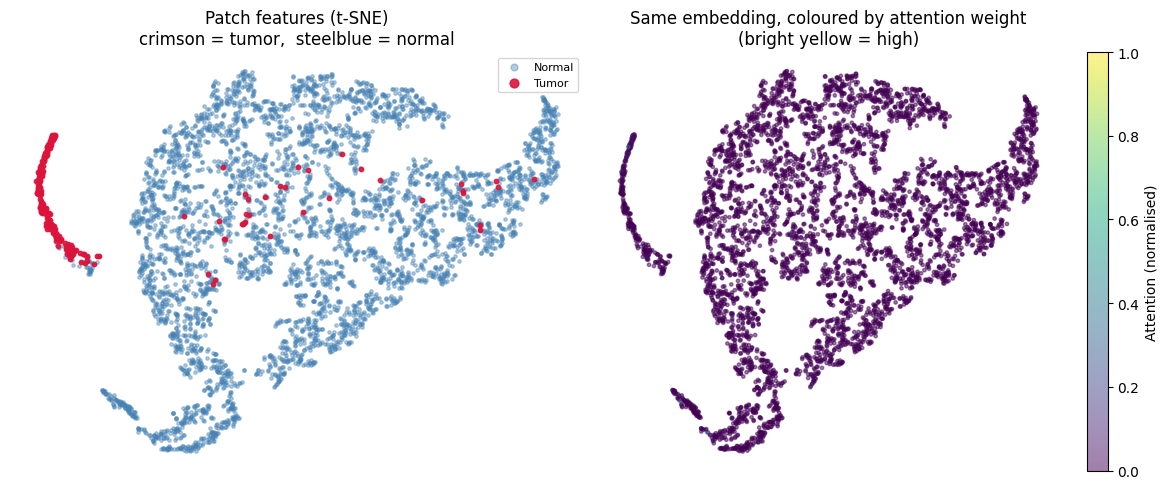

In [22]:
all_feats, all_y_inst, all_attn = [], [], []

attn_model.eval()
with torch.no_grad():
    for item in tqdm(test_loader, desc='extracting features', leave=False):
        X = item['X'].to(DEVICE)
        h = attn_model.projector(X)            # (N, HIDDEN_DIM)
        _, attn_w = attn_model.aggregator(h)
        all_feats.append(h.cpu())
        all_y_inst.append(item['y_inst'])
        all_attn.append(attn_w.cpu())

feats  = torch.cat(all_feats).numpy()
y_inst = torch.cat(all_y_inst).numpy().astype(int)
attn   = torch.cat(all_attn).numpy()

MAX_POINTS = 5000
if len(feats) > MAX_POINTS:
    sub_idx = np.random.default_rng(SEED).choice(len(feats), size=MAX_POINTS, replace=False)
    feats, y_inst, attn = feats[sub_idx], y_inst[sub_idx], attn[sub_idx]

# Global normalisation — patches are pooled across all slides so per-slide is not applicable
attn_norm = (attn - attn.min()) / (attn.max() - attn.min() + 1e-10)

print(f"Running t-SNE on {len(feats)} patches...")
coords_tsne = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(feats)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: class label — steelblue/crimson matches the rest of the notebook
ax1.scatter(coords_tsne[y_inst == 0, 0], coords_tsne[y_inst == 0, 1],
            c='steelblue', s=6, alpha=0.4, label='Normal')
ax1.scatter(coords_tsne[y_inst == 1, 0], coords_tsne[y_inst == 1, 1],
            c='crimson', s=10, alpha=0.9, zorder=5, label='Tumor')
ax1.set_title("Patch features (t-SNE)\ncrimson = tumor,  steelblue = normal")
ax1.legend(markerscale=2, fontsize=8)
ax1.axis('off')

# Right: attention weight — viridis avoids red/green conflict with left panel
sc = ax2.scatter(coords_tsne[:, 0], coords_tsne[:, 1], c=attn_norm,
                 cmap='viridis', vmin=0, vmax=1, s=6, alpha=0.5)
plt.colorbar(sc, ax=ax2, label="Attention (normalised)")
ax2.set_title("Same embedding, coloured by attention weight\n(bright yellow = high)")
ax2.axis('off')

plt.tight_layout()
plt.show()

### Misclassified Slides

Test slides predicted incorrectly, shown with the same spatial layout.

- **False positives** (label=0, pred=1): normal slide flagged as cancerous.
- **False negatives** (label=1, pred=0): cancerous slide missed.

misclassifications:   0%|          | 0/129 [00:00<?, ?it/s]

False positives: 0  (predicted positive, label negative)
False negatives: 7  (predicted negative, label positive)
No false positives on test set.

False negatives


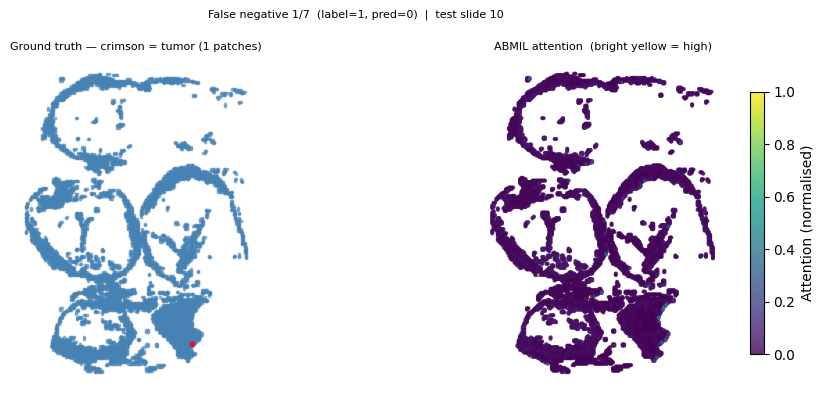

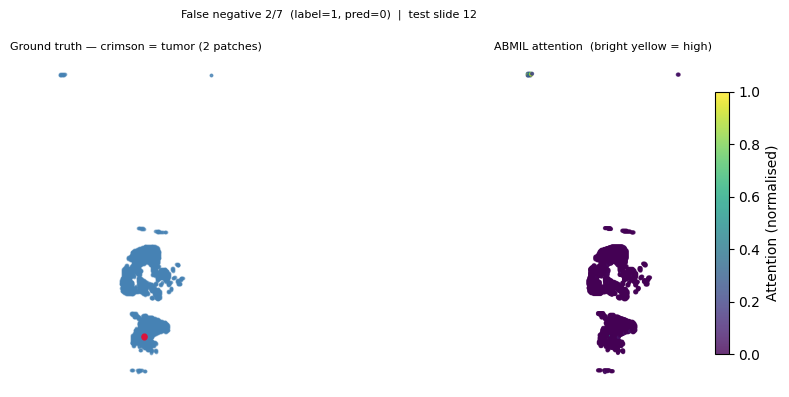

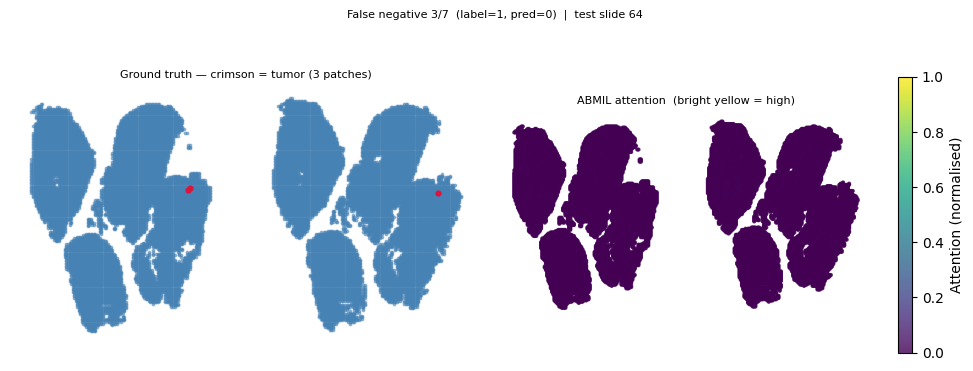

In [23]:
attn_model.eval()
fp_items, fn_items = [], []

with torch.no_grad():
    for i, item in enumerate(tqdm(test_loader, desc='misclassifications', leave=False)):
        X     = item['X'].to(DEVICE)
        label = int(item['Y'].item())
        logit, attn_w = attn_model(X)
        pred = int(torch.sigmoid(logit) > 0.5)
        entry = (
            i,
            item['coords'].numpy(),
            item['y_inst'].numpy(),
            attn_w.cpu().numpy(),
        )
        if pred == 1 and label == 0:
            fp_items.append(entry)
        elif pred == 0 and label == 1:
            fn_items.append(entry)

print(f"False positives: {len(fp_items)}  (predicted positive, label negative)")
print(f"False negatives: {len(fn_items)}  (predicted negative, label positive)")


def show_spatial_attn(coords, y_inst, attn_w, title):
    attn_w_norm = (attn_w - attn_w.min()) / (attn_w.max() - attn_w.min() + 1e-10)
    normal_mask = y_inst == 0
    tumor_mask  = y_inst == 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.scatter(coords[normal_mask, 0], -coords[normal_mask, 1],
                c='steelblue', s=3, alpha=0.5)
    if tumor_mask.any():
        ax1.scatter(coords[tumor_mask, 0], -coords[tumor_mask, 1],
                    c='crimson', s=12, alpha=1.0, zorder=5)
    n_tumor = int(tumor_mask.sum())
    ax1.set_title(f"Ground truth — crimson = tumor ({n_tumor} patches)", fontsize=8)
    ax1.set_aspect('equal')
    ax1.axis('off')

    sc = ax2.scatter(coords[:, 0], -coords[:, 1], c=attn_w_norm,
                     cmap='viridis', vmin=0, vmax=1, s=4, alpha=0.8)
    plt.colorbar(sc, ax=ax2, label="Attention (normalised)", shrink=0.8)
    ax2.set_title("ABMIL attention  (bright yellow = high)", fontsize=8)
    ax2.set_aspect('equal')
    ax2.axis('off')

    plt.suptitle(title, fontsize=8)
    plt.tight_layout()
    plt.show()


MAX_SHOW = 3

if fp_items:
    print("\nFalse positives")
    for k, (idx, coords, y_inst, attn_w) in enumerate(fp_items[:MAX_SHOW]):
        show_spatial_attn(coords, y_inst, attn_w,
            f"False positive {k+1}/{len(fp_items)}  (label=0, pred=1)  |  test slide {idx}")
else:
    print("No false positives on test set.")

if fn_items:
    print("\nFalse negatives")
    for k, (idx, coords, y_inst, attn_w) in enumerate(fn_items[:MAX_SHOW]):
        show_spatial_attn(coords, y_inst, attn_w,
            f"False negative {k+1}/{len(fn_items)}  (label=1, pred=0)  |  test slide {idx}")
else:
    print("No false negatives on test set.")